# Lifecycle Portfolio Choice Model

Three-asset lifecycle model with portfolio choice over stocks, nominal bonds, and T-bills. 
Return dynamics follow an annual VAR(1); mortality is earnings-dependent, calibrated to Chetty et al. (2016) and Catherine (2025).

| File | Contents |
|---|---|
| `model.py` | `LifecyclePortfolioModel`, `DiscretizationConfig`, `SolverConfig`; utility, bequest, income, and tax functions |
| `var.py` | VAR estimation, state/return partitioning, annualization |
| `discretization.py` | Rouwenhorst discretization, income grid, Gauss-Hermite quadrature |
| `precompute.py` | `Precompute` class; `build_model` factory |
| `solver.py` | Backward induction solver: EGM + 2D Newton-Raphson |
| `diagnostics.py` | Pre-solve calibration report, Newton failure analysis |
| `simulation.py` | Forward simulation of household lifecycle paths |
| `mortality.py` | Survival probability calibration |

In [196]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [197]:
from pathlib import Path

import numpy as np

from lifecycle.model import DiscretizationConfig, LifecyclePortfolioModel, SolverConfig
from lifecycle.predictability_ablation import (
    prepare_predictability_system,
    project_predictability_disc_config,
)
from lifecycle.precompute import build_model, Precompute
from lifecycle.solver import run_lifecycle_solver
from lifecycle.diagnostics import diagnose_all_pre, diagnose_terminal_portfolio_states, diagnose_income_post
from lifecycle.plots import plot_income_pre, plot_income_post
from lifecycle.simulation import simulate_lifecycle
from lifecycle.policy_io import save_policy_bundle, load_policy_bundle, save_sim_data, load_sim_data, list_sims


### Step 1: Estimate VAR
Estimate quarterly VAR from data, then annualise to annual frequency.
The DP model uses ANNUAL periods (ages 22-99, beta=0.96).

In [198]:
# Resolve dataset path robustly regardless of kernel launch directory.
_path_candidates = [
    Path("data/var_dataset.csv"),
    Path("../data/var_dataset.csv"),
]
_VAR_CSV = next((p for p in _path_candidates if p.exists()), None)
if _VAR_CSV is None:
    raise FileNotFoundError(
        "Could not find var_dataset.csv. Tried: "
        + ", ".join(str(p) for p in _path_candidates)
    )

PREDICTABILITY_SYSTEM = "IV"  # Choose among "I", "II", "III", "IV".


### Step 2: Parameters

All numerical choices for the model run are set here.

#### Economic calibration

In [199]:
# --- Preferences & bequest ---
gamma = 5.0          # relative risk aversion
beta  = 0.96         # annual discount factor
b_bar = 10           # bequest horizon in years (bond maturity, Catherine 2025)

# --- Lifecycle ages ---
start_age    = 22    # age at labor market entry
retire_age   = 67    # age of retirement
terminal_age = 99    # final model period

# --- Age-earnings profile (Catherine 2025) ---
# log y = b0 + b1*Age + b2*Age^2/10 + b3*Age^3/100
b0, b1, b2, b3 = -6.142, 0.3040, -0.051, 0.002586   # intercept, linear, quadratic/10, cubic/100

# --- Persistent income process (Guvenen et al. 2022) ---
# Two-component mixture: shocks drawn from high- or low-variance component each period.
rho = 0.991          # AR(1) on log permanent income
pz  = 0.176          # weight on high-variance mixture component
mu_eta1    = -0.524;  sigma_eta1 = 0.113   # low-variance component: mean, std dev
mu_eta2    = -(pz / (1.0 - pz)) * mu_eta1  # high-variance component mean (zero-mean condition, derived)
sigma_eta2 = 0.046                          # high-variance component std dev

# --- Transitory income shocks ---
mu_eps1    = 0.134;  sigma_eps1 = 0.762    # mixture component 1: mean, std dev
mu_eps2    = 0.0;    sigma_eps2 = 0.055    # mixture component 2: mean, std dev
pe         = 0.044   # mixing weight on transitory shock component 1

# --- Portfolio constraints ---
constrained = False  # False = allow leverage / short positions

base_config = {
    "beta": beta, "gamma": gamma, "b_bar": b_bar,
    "start_age": start_age, "retire_age": retire_age, "terminal_age": terminal_age,
    "b0": b0, "b1": b1, "b2": b2, "b3": b3,
    "rho": rho, "pz": pz,
    "mu_eta1": mu_eta1, "sigma_eta1": sigma_eta1,
    "mu_eta2": mu_eta2, "sigma_eta2": sigma_eta2,
    "pe": pe,
    "mu_eps1": mu_eps1, "sigma_eps1": sigma_eps1,
    "mu_eps2": mu_eps2, "sigma_eps2": sigma_eps2,
    "constrained": constrained,
}

#### Discretization and solver

Grid sizes control the accuracy of the state-space approximation. 
Solver fields below are the primary tuning knobs; numerical stability constants use class defaults in `model.py`.

In [200]:
disc_config_template = DiscretizationConfig(
    n_wealth=150,
    n_savings=150,
    state_grid_sizes=(5, 5, 5),    # System IV template axes: (cy, spr, y_1)
    state_grid_mode="principal",   # 'principal' | 'lyapunov-axis' | 'naive' (legacy default)
    state_n_stds=(0.6, 1.75, 2.0),  # scalar (broadcast to all axes) OR length-3 tuple for
                                   #   per-axis half-width. Lower-dimensional ablations
                                   #   project these template axes by state name below.
                                   # In principal mode the entries control Cholesky directions.
                                   # Default state ordering (2026-04-30) is (cy, spr, y_1):
                                   #   index 0 -> cy ONLY (clean knob, 100% of cy variance)
                                   #   index 1 -> spr (~99%, dominant lever for max|alpha_b|)
                                   #   index 2 -> residual y_1 (small leverage)
                                   # See contextfiles/RETURNS.md sec.5.6 for full mapping.
                                   # Examples:
                                   #   state_n_stds=2.0                       # uniform 2sigma
                                   #   state_n_stds=(0.5, 1.0, 2.0)           # tight cy + tight spr + wide y_1
    n_z=9,                         # Rouwenhorst grid points for permanent income
    n_stds=3.0,                    # z-grid covers +/-3 unconditional std devs
    # ---- ARBITRAGE-FREE UNCONSTRAINED CONFIG ----
    # Smallest combination that yields 0/125 discrete-quadrature arbitrages
    # at unconstrained gamma=5 (verified at state_n_stds=2.0 + K_ret=(3,5,3);
    # see RETURNS.md sec.6.12 and handoff/HANDOFF_PER_DIM_RETURN_QUADRATURE.md).
    # Income mixtures use n=3 -- minimum that matches mean/var/skew/kurt to
    # machine precision (Judd polynomial exactness 2n-1; eta kurt=4.4, eps
    # kurt=55.2; both nailed at n=3, both wildly off at n=2).
    n_eps_nodes=3,                 # transitory eps mixture
    n_eta_nodes=3,                 # persistent eta mixture
    n_ret_nodes_1d=(3, 5, 3),      # per-dim (K_rtb, K_xr, K_xb) -> 45 joint return nodes
    n_state_quad_nodes=(2, 2, 5),  # state innovation per-axis on the template axes
)

solver_config = SolverConfig(
    # --- Convergence ---
    tol=1e-7,
    max_iter=20,                   # constrained Newton
    max_iter_unconstrained=5000,   # unconstrained Newton 
    # --- Initial portfolio guess ---
    init_alpha_s=0.1,              # initial stock share
    init_alpha_b=0.4,              # initial bond share
    # --- Step control ---
    step_damp_constrained=0.2,     # max Newton step length (constrained)
    step_damp_unconstrained=0.3,   # max Newton step length (unconstrained)
    use_line_search=False,
    # --- Numerical leverage cap (unconstrained branch only) ---
    # Box projection (alpha_s, alpha_b) in [alpha_min, alpha_max]^2 applied
    # inside the unconstrained Newton. Tune so the cap is non-binding on
    # simulator-visited cells (cap-bound cells surface as EC_NEWTON_FAIL in
    # diagnostics['total_newton_failures']). Constrained branch ignores these.
    # Set to (-1e30, +1e30) to disable. Verified non-binding at gamma=5,
    # 7x7x7 wide-support, log1p (max simulated |alpha| ~9.25).
    alpha_min=-10.0,               # lower bound on alpha_s and alpha_b
    alpha_max=+10.0,               # upper bound on alpha_s and alpha_b
    # numerical stability constants -> class defaults
)

system_setup = prepare_predictability_system(
    PREDICTABILITY_SYSTEM,
    csv_path=str(_VAR_CSV),
    disc_config_template=disc_config_template,
)
var_config = system_setup["var_config"]
var_res = system_setup["var_res"]
var_data = system_setup["var_data"]
disc_config = system_setup["disc_config"]
system_code = system_setup["system_code"]
system_label = system_setup["system_label"]
system_title = system_setup["system_title"]

print(f"Selected {system_title}")
print(f"VAR builder: {system_setup['var_builder_name']}")
print(f"State vector: {system_setup['state_names']}")
print(
    "Projected discretization: "
    f"state_grid_sizes={disc_config.state_grid_sizes}, "
    f"n_state_quad_nodes={disc_config.n_state_quad_nodes}, "
    f"state_n_stds={disc_config.state_n_stds}"
)

VAR ESTIMATION SUMMARY
Estimation mode: restricted_constrained
Sample rows: 63
Columns: ['y_1', 'spr', 'cy', 'rtb', 'xr', 'xb']
State indices: (2, 1, 0)
Return indices: (3, 4, 5)
VAR k=6, T=62
Max |Phi[:, return_lag_cols]|: 0.000e+00

Intercept vector (const):
[ 0.062312 -0.025114 -0.242387 -0.162459  0.471994 -0.311008]

Residual correlation matrix:
[[ 1.     -0.8646  0.1664 -0.4893 -0.0963 -0.7144]
 [-0.8646  1.      0.0066  0.289  -0.0794  0.299 ]
 [ 0.1664  0.0066  1.     -0.4272 -0.9807 -0.3178]
 [-0.4893  0.289  -0.4272  1.      0.3046  0.502 ]
 [-0.0963 -0.0794 -0.9807  0.3046  1.      0.2904]
 [-0.7144  0.299  -0.3178  0.502   0.2904  1.    ]]

Equation R2:
  y_1: 0.7843
  spr: 0.5211
  cy: 0.8733
  rtb: 0.5179
  xr: 0.0591
  xb: 0.3215
Selected System IV (full VAR baseline)
VAR builder: build_nominal_system1_var_config
State vector: ('cy', 'spr', 'y_1')
Projected discretization: state_grid_sizes=(5, 5, 5), n_state_quad_nodes=(2, 2, 5), state_n_stds=(0.6, 1.75, 2.0)


#### Simulation & Bundle Configuration

Set `BUNDLE` to the solver output directory for this run.  
All downstream operations (simulation, saving, loading) use this path.

In [201]:
# -- Bundle path -------------------------------------------------------------
# Change this to switch between solver runs. Everything below flows from BUNDLE.
# Path includes predictability system, constraint flag, and state_grid_mode so
# different runs don't overwrite each other.

_constraint_label = "constrained" if base_config["constrained"] else "unconstrained"
BUNDLE = Path("saved_runs") / (
    f"{system_label}_{_constraint_label}_{disc_config.state_grid_mode}"
    f"_grid{'x'.join(map(str, disc_config.state_grid_sizes))}_nz{disc_config.n_z}_v2"
    # _v2 marks the post-2026-04-30 redesign: cy-first VAR ordering, Cholesky
    # return quadrature, per-axis state_n_stds + n_state_quad_nodes.
)

# -- Simulation defaults -----------------------------------------------------

sim_defaults = dict(
    n_simulations       = 10_000,
    seed                = 42,
    initial_wealth      = 0.1,
    initial_z           = "normal",
    initial_z_normal_std = 0.652,
    initial_state       = "median",
    return_draw_mode    = "monte_carlo",
)

def _decode_jsonable_metadata(value):
    if isinstance(value, dict):
        if value.get("kind") == "ndarray":
            if "values" not in value:
                raise ValueError(
                    "Bundle metadata contains an ndarray without embedded values. "
                    "Cannot reconstruct the simulation runtime from this bundle."
                )
            return np.asarray(value["values"], dtype=np.dtype(value["dtype"]))
        return {k: _decode_jsonable_metadata(v) for k, v in value.items()}
    if isinstance(value, list):
        return [_decode_jsonable_metadata(v) for v in value]
    return value


def _tupleize_if_list(value):
    return tuple(value) if isinstance(value, list) else value


def _rebuild_bundle_simulation_context(meta, *, verbose=False):
    run_cfg = _decode_jsonable_metadata(meta.get("run_config", {}))
    required = ("base_config", "var_config", "discretization_config")
    missing = [key for key in required if key not in run_cfg]
    if missing:
        raise ValueError(
            "Bundle metadata is missing the run_config fields required to rebuild "
            f"the simulation runtime: {missing}"
        )

    bundle_base_config = dict(run_cfg["base_config"])
    bundle_var_config = dict(run_cfg["var_config"])
    bundle_disc_dict = dict(run_cfg["discretization_config"])

    if "constrained" in run_cfg:
        bundle_base_config["constrained"] = bool(run_cfg["constrained"])

    for key in ("state_grid_sizes", "n_ret_nodes_1d", "n_state_quad_nodes", "state_n_stds"):
        if key in bundle_disc_dict:
            bundle_disc_dict[key] = _tupleize_if_list(bundle_disc_dict[key])

    bundle_disc_config = DiscretizationConfig(**bundle_disc_dict)
    bundle_model = build_model(bundle_base_config, bundle_var_config, verbose=verbose)
    bundle_pc = Precompute(bundle_model, bundle_disc_config, verbose=verbose)
    return bundle_model, bundle_pc, run_cfg


def run_sim(bundle_dir, label="baseline", verbose=True, save=True, **overrides):
    """Load policies from bundle, rebuild the matching runtime, and simulate."""
    C_mat_sim, S_mat_sim, B_mat_sim, _, meta = load_policy_bundle(bundle_dir)
    bundle_model, bundle_pc, bundle_run_cfg = _rebuild_bundle_simulation_context(
        meta,
        verbose=False,
    )
    bundle_ablation = bundle_run_cfg.get("predictability_ablation", {})
    bundle_system = bundle_ablation.get("system_label", "unknown_system")
    expected_shape = (bundle_pc.n_age, bundle_pc.n_z, bundle_pc.N_state, bundle_pc.n_w)
    if (
        tuple(C_mat_sim.shape) != expected_shape
        or tuple(S_mat_sim.shape) != expected_shape
        or tuple(B_mat_sim.shape) != expected_shape
    ):
        raise ValueError(
            "Loaded policy arrays do not match the runtime rebuilt from bundle metadata. "
            f"Expected {expected_shape}, got C={tuple(C_mat_sim.shape)}, "
            f"S={tuple(S_mat_sim.shape)}, B={tuple(B_mat_sim.shape)}."
        )

    kw = {**sim_defaults, **overrides}
    print(f"\n{'-'*40}\nSimulation: {label}\n{'-'*40}")
    print(f"  Bundle: {bundle_dir}")
    print(f"  Runtime: {bundle_system} / grid {bundle_pc.state_grid.shape}")
    sd = simulate_lifecycle(
        C_mat_sim,
        S_mat_sim,
        B_mat_sim,
        bundle_pc,
        bundle_model,
        verbose=verbose,
        **kw,
    )
    sd['label'] = label
    sd['bundle_system'] = bundle_system
    if save:
        save_sim_data(bundle_dir, sd, label, sim_config=kw, overwrite=True)
        print(f"\n  Saved sim '{label}' -> {bundle_dir}/sims/")
    return sd

print(f"{system_title}: BUNDLE = {BUNDLE}")
print(f"Available sims: {list_sims(BUNDLE)}")


System IV (full VAR baseline): BUNDLE = saved_runs\system_iv_full_var_unconstrained_principal_grid5x5x5_nz9_v2
Available sims: []


### Step 3: Build Model and Precompute

Assembles `LifecyclePortfolioModel` from `base_config` and the estimated VAR, 
then precomputes grids, transitions, and income quadrature.

In [202]:
def refresh_model_if_stale(model_obj=None, *, constrained=None, verbose=False):
    """Rebuild the model from the current notebook configs.

    Under IPython autoreload, NamedTuple layout changes and same-layout VAR
    updates can both leave stale model objects in memory. Rebuilding from the
    current `base_config` + `var_config` is cheap relative to solve time and
    avoids silently mixing an old model with new notebook settings.
    """
    rebuilt = build_model(base_config, var_config, verbose=verbose)

    if constrained is not None and bool(rebuilt.constrained) != bool(constrained):
        rebuilt = rebuilt._replace(constrained=bool(constrained))

    return rebuilt


model = build_model(base_config, var_config, verbose=True)
pc    = Precompute(model, disc_config)


VAR PARTITION SUMMARY
Full variables: ['y_1', 'spr', 'cy', 'rtb', 'xr', 'xb']
State variables (on grid): ['cy', 'spr', 'y_1']
Return variables (integrated): ['rtb', 'xr', 'xb']

Slow-state sub-VAR:
  Phi_11 eigenvalues (|.|): [0.9362, 0.7748, 0.7748]
  Max |eigenvalue| = 0.9362  --  STATIONARY

Restriction check (should be near zero if imposed):
  ||Phi_12|| = 0.000000e+00   (lagged returns -> states)
  ||Phi_22|| = 0.000000e+00   (lagged returns -> returns)

Conditional return variance explained by slow-state conditioning:
  rtb:  39.05%  explained  (residual var = 0.000239)
  xr:  96.21%  explained  (residual var = 0.000957)
  xb:  91.21%  explained  (residual var = 0.000511)

  EARNINGS-DEPENDENT MORTALITY CALIBRATION
  Catherine (2025) eq. (35), conditioned on persistent income z
  Income params: rho=0.9910  sigma_z=1.8697
  z grid: 9 pts  [-5.6090, 5.6090]
  SSA table: 2017 (2020 TR), gender-averaged
  Targets: Chetty et al. (2016), race-adjusted, gender-averaged

         z  pcti

### Step 4: Pre-Solve Diagnostics

In [203]:
pre_results = diagnose_all_pre(model, pc)

# Terminal-stage portfolio diagnostic before the full lifecycle solve.
terminal_diag = diagnose_terminal_portfolio_states(model, pc)


  LABOUR INCOME & SOCIAL SECURITY

  -- Income Process Parameters ---------------------------------------------
  rho        = 0.99100  (per-period persistence)
  pz         = 0.176    (mixture weight on component 1)
  Component 1:  mu_eta1 = -0.5240,  sigma_eta1 = 0.1130
  Component 2:  mu_eta2 = +0.1119,  sigma_eta2 = 0.0460
  E[eta]     = 0.00e+00   (should be ~ 0)
  Std[eta]   = 0.25028
  Std[z]     = 1.86966  (unconditional)
  z_grid     : 9 points  [-5.6090, 5.6090]   +/-3.00 sigma

  pe            = 0.044   (probability of large-shock component)
  Component 1:  mu_eps1    = +0.1340,  sigma_eps1 = 0.7620
  Component 2:  mu_eps2_eff = -0.0062  (zero-mean enforced)
               sigma_eps2 = 0.0550
  E[eps]        = 3.47e-18   (should be ~ 0)
  Var[eps]      = 0.02927   Std[eps] = 0.17108
  eps_nodes     : 3 nodes  [-1.0794, 1.3943]
  E[exp(eps)]   = 1.0187   (Jensen: >1 by ~0.5*Var; +1.9%)

  Deterministic profile: b0=-6.1420, b1=0.3040, b2=-0.0510, b3=0.002586
  Hump peak: age 

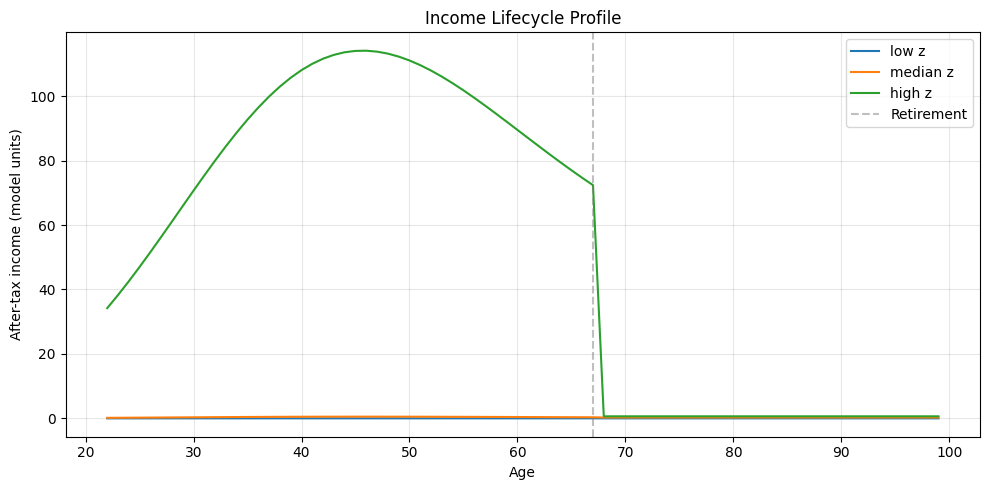

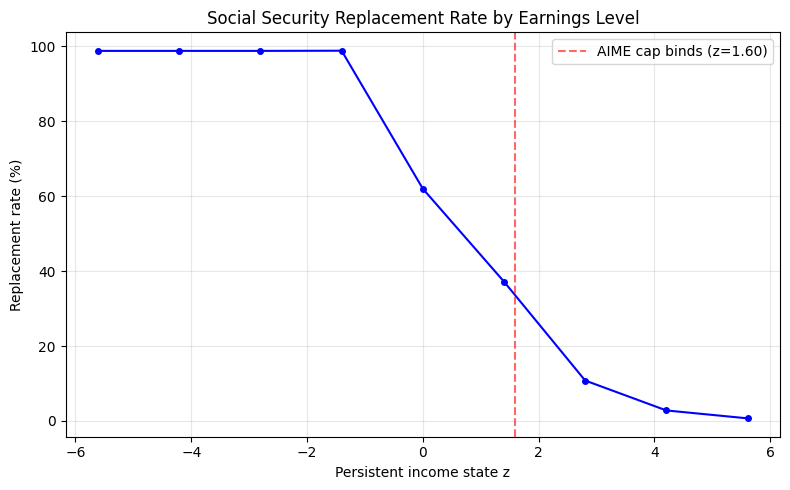

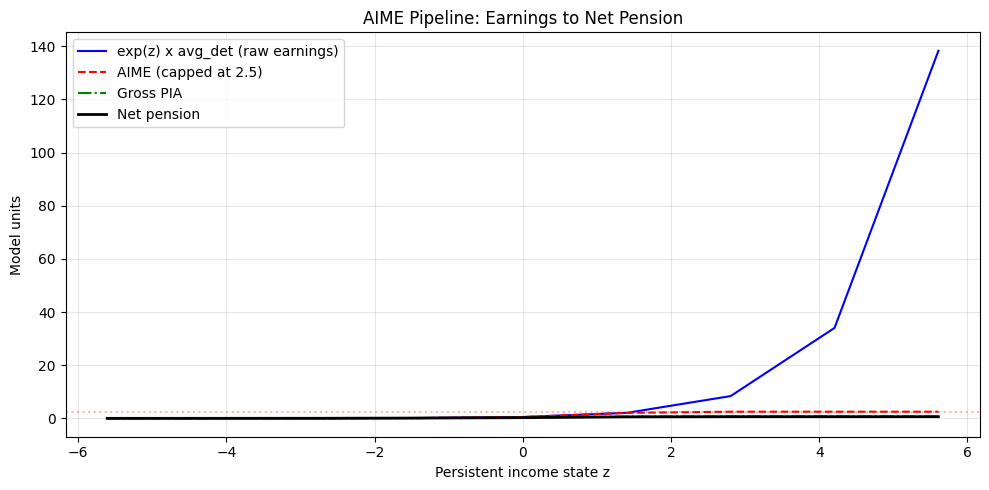

In [194]:
figs_pre = plot_income_pre(model, pc)

### Step 5: Solve
First call triggers Numba JIT compilation (~30-60s); subsequent calls are fast.

In [ ]:
# -- Solve --
model = refresh_model_if_stale(
    globals().get("model"),
    constrained=base_config["constrained"],
    verbose=False,
)
pc = Precompute(model, disc_config)

C_mat, S_mat, B_mat, diagnostics = run_lifecycle_solver(model, pc, solver_config=solver_config)

run_config = {
    "base_config": base_config,
    "discretization_config": disc_config._asdict(),
    "solver_config": solver_config._asdict(),
    "var_config": var_config,
    "predictability_ablation": {
        "system_code": system_code,
        "system_label": system_label,
        "system_title": system_title,
        "var_builder_name": system_setup["var_builder_name"],
        "state_names": list(system_setup["state_names"]),
    },
    "constrained": bool(model.constrained),
    "solve_label": _constraint_label,
}

bundle_path = save_policy_bundle(
    BUNDLE,
    C_mat,
    S_mat,
    B_mat,
    diagnostics=diagnostics,
    run_config=run_config,
    overwrite=True,
)
print(f"Saved {_constraint_label} policy bundle to: {bundle_path}")


In [ ]:
# -- Unconstrained solve (separate run, reuses same Precompute) --
# Inherits solver_config from the constrained solve, with these overrides:
#   - max_iter_unconstrained: unconstrained Newton has a larger search space
#     (no simplex projection) and may need more iterations to converge.
#   - init_alpha_s/init_alpha_b: aligned with observed median-state optima
#     (~0.85 stock, ~0.44 bond -> implied -0.29 bill leverage). Cuts iterations
#     for cold starts at each new (i_s, z_i) chain and after warm-resets.
#   - use_line_search=True: backtracking line search with monotone decrease
#     on ||FOC||. Safe with the #1 stagnation-exit fix in solver.py: any failure
#     to find a descent step exits cleanly with EC_NEWTON_FAIL instead of
#     spinning. Expected to dramatically cut max_it on the slow tail of states.
model = refresh_model_if_stale(
    globals().get("model"),
    constrained=base_config["constrained"],
    verbose=False,
)
pc = Precompute(model, disc_config)
model_unc = refresh_model_if_stale(
    globals().get("model_unc"),
    constrained=False,
    verbose=False,
)
solver_config_unc = solver_config._replace(
    max_iter_unconstrained=8000,
    init_alpha_s=0.85,
    init_alpha_b=0.44,
    use_line_search=True,
)

C_mat_unc, S_mat_unc, B_mat_unc, diagnostics_unc = run_lifecycle_solver(model_unc, pc, solver_config=solver_config_unc)

run_config_unconstrained = {
    "base_config": {**base_config, "constrained": False},
    "discretization_config": disc_config._asdict(),
    "solver_config": solver_config_unc._asdict(),
    "var_config": var_config,
    "predictability_ablation": {
        "system_code": system_code,
        "system_label": system_label,
        "system_title": system_title,
        "var_builder_name": system_setup["var_builder_name"],
        "state_names": list(system_setup["state_names"]),
    },
    "constrained": bool(model_unc.constrained),
    "solve_label": "unconstrained",
}

unconstrained_bundle_path = Path("saved_runs") / (
    f"{system_label}_unconstrained_{disc_config.state_grid_mode}"
    f"_grid{'x'.join(map(str, disc_config.state_grid_sizes))}_nz{disc_config.n_z}_v2"
    # _v2 marks the post-2026-04-30 redesign: cy-first VAR ordering, Cholesky
    # return quadrature, per-axis state_n_stds + n_state_quad_nodes.
)
unconstrained_bundle = save_policy_bundle(
    unconstrained_bundle_path,
    C_mat_unc,
    S_mat_unc,
    B_mat_unc,
    diagnostics=diagnostics_unc,
    run_config=run_config_unconstrained,
    overwrite=True,
)
print(f"Saved unconstrained policy bundle to: {unconstrained_bundle}")



  EARNINGS-DEPENDENT MORTALITY CALIBRATION
  Catherine (2025) eq. (35), conditioned on persistent income z
  Income params: rho=0.9910  sigma_z=1.8697
  z grid: 9 pts  [-5.6090, 5.6090]
  SSA table: 2017 (2020 TR), gender-averaged
  Targets: Chetty et al. (2016), race-adjusted, gender-averaged

         z  pctile      chi   target   actual  err(yr)
  -------- ------- -------- -------- -------- --------
   -5.6090     1.0  1.37540    75.76    75.76 -0.00000
   -4.2067     1.2  1.32658    76.14    76.14 -0.00000
   -2.8045     6.7  1.01456    78.97    78.97 -0.00000
   -1.4022    22.7  0.86462    80.66    80.66 -0.00000
    0.0000    50.0  0.66934    83.35    83.35 -0.00000
    1.4022    77.3  0.55679    85.30    85.30 -0.00000
    2.8045    93.3  0.47412    87.02    87.02 -0.00000
    4.2067    98.8  0.44360    87.73    87.73 -0.00000
    5.6090    99.9  0.43023    88.06    88.06 -0.00000

  Survival probs at key ages (lowest z -> highest z):
    Age  40:  low-z=0.996454  high-z=0.9988

In [ ]:
§# -- Partial solve: from-age65 attribution run on the new log1p grids --
# Wide-support config (2.0, 2.25, 2.25) on a 7x7x7 grid, ages 65-99.
# Stacks restretched savings/wealth grids + wider state support relative to
# the prior _v2 baseline. Bundle marked _log1p to keep diagnostics clean.
from lifecycle.model import SolveControl

# Prefer the tuned unconstrained setup if that cell has been run; otherwise
# fall back to the baseline model / solver config currently in memory.
model = refresh_model_if_stale(
    globals().get("model"),
    constrained=base_config["constrained"],
    verbose=False,
)
if "model_unc" in globals():
    model_unc = refresh_model_if_stale(
        globals().get("model_unc"),
        constrained=False,
        verbose=False,
    )
run_model = model_unc if "model_unc" in globals() else model
run_solver_config = solver_config_unc if "solver_config_unc" in globals() else solver_config

attribution_template = disc_config_template._replace(
    state_grid_sizes=(7, 7, 7),
    state_n_stds=(2.0, 2.25, 2.25),     # widened -- was (0.6, 1.75, 2.0)
    n_ret_nodes_1d=(3, 7, 5),           # frozen kret
    n_state_quad_nodes=(2, 2, 5),       # unchanged
)
disc_config_attribution = project_predictability_disc_config(
    attribution_template,
    run_model.state_names,
)

pc_attribution = Precompute(run_model, disc_config_attribution)

mode_label = "constrained" if run_model.constrained else "unconstrained"
youngest_partial_age = 65                # ages 65-99: 2 working + 33 retirement
ns_label = 'x'.join(str(v).replace('.', 'p') for v in np.atleast_1d(disc_config_attribution.state_n_stds))
ret_label = 'x'.join(map(str, np.atleast_1d(disc_config_attribution.n_ret_nodes_1d)))
attribution_checkpoint = Path("saved_runs") / "checkpoints" / (
    f"{system_label}_{mode_label}_{disc_config_attribution.state_grid_mode}"
    f"_grid{'x'.join(map(str, disc_config_attribution.state_grid_sizes))}"
    f"_nz{disc_config_attribution.n_z}_from_age{youngest_partial_age}_kret{ret_label}"
    f"_ns{ns_label}_log1p_v1"
)

solve_control = SolveControl(
    youngest_age_to_solve=youngest_partial_age,
    checkpoint_path=str(attribution_checkpoint),
    checkpoint_every_n_ages=1,
    save_on_interrupt=True,
    return_partial_on_interrupt=True,
)

print(f"Running {system_title} {mode_label} partial solve for ages {youngest_partial_age}-{run_model.terminal_age}")
print(f"Discretization: {disc_config_attribution}")
print(f"Solver config: {run_solver_config}")
print(f"Checkpoint bundle: {attribution_checkpoint}")

C_mat_attribution, S_mat_attribution, B_mat_attribution, diagnostics_attribution = run_lifecycle_solver(
    run_model,
    pc_attribution,
    solver_config=run_solver_config,
    solve_control=solve_control,
)

print(f"status: {diagnostics_attribution['solve_status']}")
print(f"partial: {diagnostics_attribution['is_partial']}")
print(
    f"solved ages: {diagnostics_attribution['youngest_solved_age']}"
    f"-{diagnostics_attribution['oldest_solved_age']}"
)
print(f"checkpoint bundle: {diagnostics_attribution['last_saved_bundle_path']}")

C_chk, S_chk, B_chk, diag_chk, meta_chk = load_policy_bundle(attribution_checkpoint)
print(f"loaded status: {diag_chk['solve_status']}")
print(f"bundle shape: {meta_chk['shape']}")
